# 02 · Разметка: что считать слабым сигналом

**Зачем этот шаг.** Чтобы учить модель, нужны ответы: в какой год технология
была слабым сигналом, а в какой — нет. Готовых ответов нет: организаторы дали
только 100 положительных примеров на сегодня, а нам нужна история. Размечать
тысячи технологий вручную долго, поэтому первую разметку делает LLM, а люди её
проверяют.

**Что видит LLM.** Одна технология — один запрос. В запросе: её история по
годам в нашем корпусе (сколько документов, сколько новых за год, сколько
независимых команд, организаций, компаний, типов источников) и датированные
заголовки документов. Модель судит траекторию целиком, опираясь и на эти
данные, и на свои знания о предметной области.

**Что возвращает LLM** — по каждому году истории:

| Поле | Смысл |
|---|---|
| **оценка** | 0 — в этот год технология была слабым сигналом (ранняя, мало независимых команд, потом выросла или нашла нишу); 1 — точно не слабый сигнал (шум, угасла или уже мейнстрим) |
| **перегретость** | 0..1 — насколько внимание обгоняло реальное содержание (хайп) |
| **сформированность** | 0..1 — от идеи (0) через прототипы (0,5) к массовому внедрению (1) |

и по технологии в целом — **вердикт** траектории и признак **«это вообще технология»**.

**Важно.** LLM видела будущее технологии, поэтому это *метки* для обучения, а не
признаки: в модель они не попадают. Метки LLM шумные — это не экспертная истина.

Код: `src/lctrend/modeling/dataset/llm_outcomes.py`. Размечает ключ GigaChat
`Разметка`; повторный запуск продолжает с места остановки:
`python -m lctrend.modeling.dataset.llm_outcomes --from-graph --output <run>/dataset/llm_labels.csv`

**Где мы в цепочке**

1. **01 · выгрузка** — что есть в графе на каждую дату (признаки и окружение технологий);
2. **02 · разметка** — что LLM считает слабым сигналом в каждый год;
3. **03 · выборка** — соединяем 01 и 02 в обучающую таблицу;
4. **04 · обучение** — CatBoost, HGT и их комбинация, метрики;
5. **05 · граф** — записываем итоговую разметку в узлы технологий.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from lab import *
from IPython.display import display, Markdown

answers = read_jsonl(DATASET_DIR / "llm_labels.csv.jsonl")
answers = answers[answers.status == "ok"].drop_duplicates("technology_id", keep="last")
answers["is_technology"] = answers.is_technology.astype(bool)
# Модель, разметившая основную часть, в отчётах не называется: GigaChat — по имени, остальные — «основная разметка».
answers["model"] = answers.model.where(answers.model.str.startswith("GigaChat"), "основная разметка")
yearly = read(DATASET_DIR / "llm_labels_by_year.csv")
overview = pd.DataFrame(
    [("Технологий размечено", len(answers)), ("Пар «технология × год»", len(yearly)),
     *[(f"Разметила модель {model}", count) for model, count in answers.model.value_counts().items()]],
    columns=["Показатель", "Значение"]).set_index("Показатель")
display(overview.style.format(num))

,Значение
Показатель,
Технологий размечено,3 106
Пар «технология × год»,18 235
Разметила модель основная разметка,2 985
Разметила модель GigaChat-3-Ultra,121


## 1. Вердикты по траекториям

**Зачем смотрим.** Вердикт — короткий итог всей истории технологии. Он
показывает, из чего состоит наш корпус: много ли в нём настоящих технологий,
сколько «мусора» и сколько уже зрелых направлений.

,технологий,доля,что значит
вердикт,,,
junk,1197,39%,не настоящая технология или чистый шум
mainstream,693,22%,была мейнстримом ещё до первого года в корпусе
niche,657,21%,выжила и нашла свою нишу
success,211,7%,стала устойчивым трендом или широко внедрена
faded,188,6%,привлекла внимание и угасла
unclear,160,5%,по данным не понять


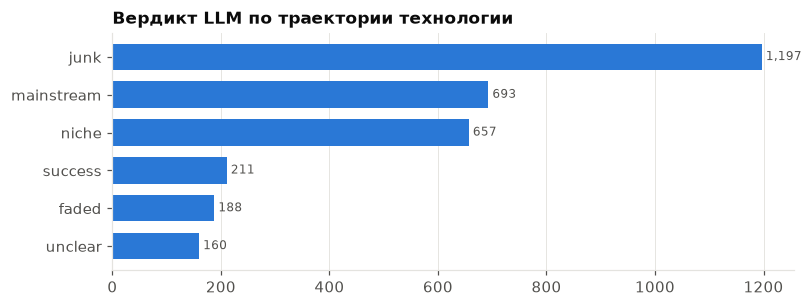

In [2]:
MEANING = {
    "success": "стала устойчивым трендом или широко внедрена",
    "niche": "выжила и нашла свою нишу",
    "faded": "привлекла внимание и угасла",
    "junk": "не настоящая технология или чистый шум",
    "mainstream": "была мейнстримом ещё до первого года в корпусе",
    "unclear": "по данным не понять",
}
verdicts = answers.verdict.value_counts()
display(pd.DataFrame({"технологий": verdicts, "доля": (verdicts / len(answers)).map("{:.0%}".format),
                      "что значит": verdicts.index.map(MEANING)}).rename_axis("вердикт"))
fig, ax = plt.subplots(figsize=(8, 2.8))
bar(ax, verdicts.index, verdicts.values, horizontal=True)
ax.set_title("Вердикт LLM по траектории технологии")
plt.show()

## 2. Шум: названия, которые не являются технологиями

**Зачем.** При извлечении из статей в граф попадают обрывки фраз, названия
самих статей, аббревиатуры, придуманные в одной работе. Учить на них модель
вредно: это не технологии, и никакой «судьбы» у них нет. LLM помечает такие
названия, их строки не размечаются, но остаются соседями в подграфах.
Список сохраняется в `noise_technologies.csv` — пригодится для чистки графа и поиска.

In [3]:
noise = answers[~answers.is_technology][["technology_id", "technology", "verdict", "rationale"]]
noise.to_csv(DATASET_DIR / "noise_technologies.csv", index=False)
display(Markdown(f"**{num(len(noise))}** из {num(len(answers))} ({len(noise) / len(answers):.0%}) — не технологии. Случайные примеры с объяснением LLM:"))
display(noise.sample(10, random_state=1)[["technology", "rationale"]].rename(
    columns={"technology": "название", "rationale": "почему не технология"}).style.hide(axis="index"))

**1 188** из 3 106 (38%) — не технологии. Случайные примеры с объяснением LLM:

название,почему не технология
Edge Machine Learning for AI-Enabled IoT Devices,"The term is an extraction artifact taken directly from the title of a review paper ('Edge Machine Learning for AI-Enabled IoT Devices: A Review'). While Edge AI and TinyML are valid technology paradigms, this specific phrase represents a descriptive paper title rather than a discrete technology."
Dexterous Soft Robotic Hand for Delicate In-Hand Manipulation,"This entry is a verbatim extraction of a single research paper title rather than an established or distinct technology concept. While soft robotic hands and in-hand manipulation are valid research topics, this specific phrase represents an artifact of document title parsing."
Proof-of-Work–подобный майнинг с difficulty-adaptive incentives,This candidate is a mixed-language extraction artifact describing an ad-hoc consensus variation from a single research paper rather than a recognized technology or standalone method.
Harm penalty biasing of Q-values,"""Harm penalty biasing of Q-values"" is an ad-hoc baseline technique described in a single paper (the MACHIAVELLI benchmark) rather than a distinct, recognized technology. It represents standard reward-shaping and constrained reinforcement learning formulations under a paper-specific descriptive label."
Cloud and edge computing devices,"""Cloud and edge computing devices"" is an overly broad, generic category phrase rather than a concrete technology or novel method. Furthermore, both cloud infrastructure and edge computing hardware were already mature, mainstream paradigms well before 2024."
Gather,"""Gather"" is a common English verb often used in project descriptions (e.g., gathering data or community engagement) or a basic primitive in collective communication/tensor indexing. In this corpus, it represents an extraction artifact capturing unrelated research grants and papers rather than a distinct emerging technology."
Blockchain-based distributed learning for multicentric medical imaging (C-DistriM),The candidate name is a paper title and one-off project acronym rather than an established independent technology or widely adopted framework. It has no documented community adoption or continuation beyond the single 2020 publication.
Local Differential Randomization,"'Local Differential Randomization' is an ad-hoc phrase or extraction artifact conflating Local Differential Privacy (LDP) mechanisms with local randomization techniques. It does not exist as an independent, recognized technology or standard methodology."
PFMLP,"""PFMLP"" appears to be an ad-hoc acronym or extraction artifact derived from papers discussing privacy-preserving federated machine learning. It does not designate a distinct, recognizable technology or established framework."
Computer Security Incident Handling Guide,"""Computer Security Incident Handling Guide"" is the title of a specific NIST Special Publication (NIST SP 800-61) rather than a discrete technology or method. It represents an extraction artifact of a document title."


## 3. Оценки по годам и как они становятся ответом для модели

**Зачем.** Модель учится на двух классах: «слабый сигнал» и «не слабый».
Оценку LLM переводим в класс по порогам из конфига: оценка не выше
`weak_max` — слабый сигнал (класс 1), не ниже `not_weak_min` — не слабый
(класс 0). Середина — LLM не уверена, такие годы не размечаем: лучше меньше
примеров, чем спорные.

**Как читать.** Гистограмма — сколько пар «технология × год» получили каждую
оценку; пунктиры — пороги.

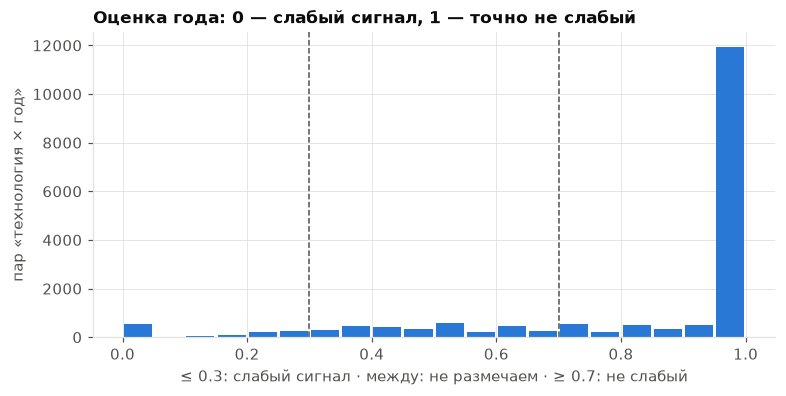

,пар,доля
класс,,
слабый сигнал (класс 1),1498,8%
не уверен (не размечаем),2683,15%
не слабый (класс 0),14054,77%


**Вывод.** Слабых сигналов 8% — класс редкий. Модель будет учиться с балансировкой классов, а качество мерить метриками, чувствительными к редкому классу (PR-AUC, шаг 04).

In [4]:
weak_max = CONFIG["labels"]["weak_max"]
not_weak_min = CONFIG["labels"]["not_weak_min"]
fig, ax = plt.subplots()
ax.hist(yearly.llm_score, bins=[i / 20 for i in range(21)], color=BLUE, rwidth=0.9)
for x in (weak_max, not_weak_min):
    ax.axvline(x, color=MUTED, linewidth=1, linestyle="--")
ax.set_title("Оценка года: 0 — слабый сигнал, 1 — точно не слабый")
ax.set_xlabel(f"≤ {weak_max}: слабый сигнал · между: не размечаем · ≥ {not_weak_min}: не слабый")
ax.set_ylabel("пар «технология × год»")
plt.show()
bucket = pd.cut(yearly.llm_score, [-0.01, weak_max, not_weak_min - 1e-9, 1],
                labels=["слабый сигнал (класс 1)", "не уверен (не размечаем)", "не слабый (класс 0)"])
counts = bucket.value_counts().reindex(bucket.cat.categories)
display(pd.DataFrame({"пар": counts, "доля": (counts / len(yearly)).map("{:.0%}".format)}).rename_axis("класс"))
display(Markdown(
    f"**Вывод.** Слабых сигналов {counts.iloc[0] / len(yearly):.0%} — класс редкий. Модель будет учиться с "
    "балансировкой классов, а качество мерить метриками, чувствительными к редкому классу (PR-AUC, шаг 04)."
))

## 4. Как меняются оценки со временем

**Зачем.** Если средние оценки резко скачут по годам, модель может выучить
«год», а не «сигнал». Смотрим средние по годам среза.

**Как читать.** Три линии на одной шкале 0..1: оценка (ниже — больше слабых
сигналов), перегретость и сформированность.

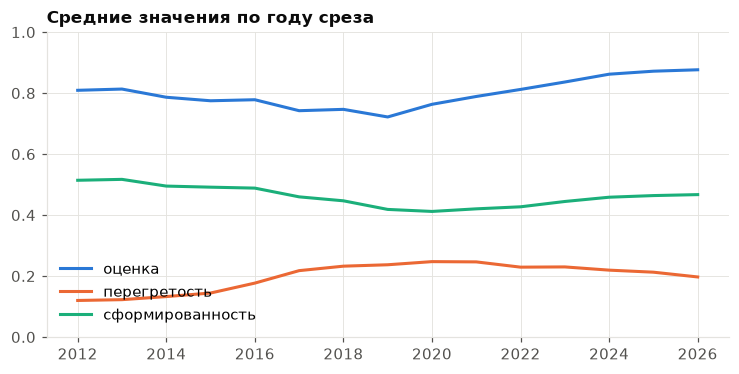

In [5]:
by_year = yearly[yearly.year >= 2012].groupby("year")[["llm_score", "llm_hype", "llm_maturity"]].mean()
fig, ax = plt.subplots()
for column, label in (("llm_score", "оценка"), ("llm_hype", "перегретость"), ("llm_maturity", "сформированность")):
    ax.plot(by_year.index, by_year[column], label=label)
ax.set_ylim(0, 1)
ax.set_title("Средние значения по году среза")
ax.legend(loc="lower left")
plt.show()

## 5. Траектории: как LLM видит конкретные технологии

**Зачем.** Проверить глазами, что оценки осмысленны. Берём по одной
технологии с вердиктами «успех», «угасла» и «ниша», у которых история не
короче пяти лет.

**Как читать.** Голубая полоса снизу — зона слабого сигнала. У успешной
технологии оценка обычно начинается низко (ранний сигнал) и растёт к 1, когда
технология становится мейнстримом.

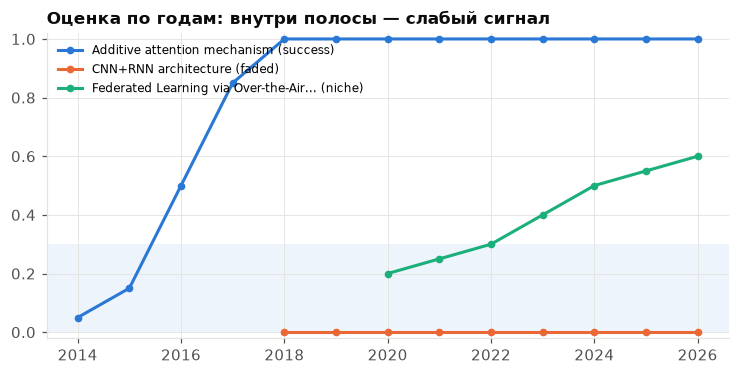

технология,вердикт,обоснование LLM
Additive attention mechanism,success,"Introduced by Bahdanau et al. in 2014, additive attention was the foundational breakthrough that introduced attention mechanisms to deep learning and neural machine translation. Although later partially superseded by scaled dot-product attention in Transformer architectures, it revolutionized NLP and artificial intelligence architectures."
CNN+RNN architecture,faded,"The CNN+RNN architecture for vision-language tasks was a prominent approach around 2018 but saw no new research after the initial signal, indicating it was superseded by transformer-based models. The static record of one document and two companies suggests an abandoned line rather than sustained development."
Federated Learning via Over-the-Air Computation,niche,"Over-the-air computation for federated learning (AirFL) exploits the superposition property of wireless channels to compute model aggregations directly over the air. It has become a sustained, highly studied research niche within 6G wireless communication and Edge AI, though real-world deployment remains constrained by synchronization and channel estimation challenges."


In [6]:
long = answers[answers.years.map(len) >= 5]
examples = pd.concat([long[long.verdict == v].head(1) for v in ("success", "faded", "niche")])
fig, ax = plt.subplots()
for _, item in examples.iterrows():
    years = pd.DataFrame(item.years)
    ax.plot(years.year, years.score, marker="o", markersize=4, label=f"{short(item.technology, 40)} ({item.verdict})")
ax.axhspan(0, weak_max, color="#eef4fc", zorder=0)
ax.set_ylim(-0.02, 1.02)
ax.set_title("Оценка по годам: внутри полосы — слабый сигнал")
ax.legend(loc="upper left", fontsize=8)
plt.show()
display(examples[["technology", "verdict", "rationale"]].rename(
    columns={"technology": "технология", "verdict": "вердикт", "rationale": "обоснование LLM"}).style.hide(axis="index"))

## 6. Однородность меток

**Зачем.** Если часть технологий разметила одна модель, а часть — другая, и
они судят по-разному, метки получаются неоднородными: модель выучит разницу
между разметчиками. Сравниваем распределения вердиктов основной разметки и доразметки GigaChat.

**Как читать.** Строка — модель, числа — доля каждого вердикта. Близкие
строки — метки однородны; сильное расхождение — часть стоит переразметить одной моделью.

In [7]:
display(pd.concat([
    pd.crosstab(answers.model, answers.verdict, normalize="index").round(2),
    answers.groupby("model").is_technology.mean().round(2).rename("доля технологий"),
    answers.model.value_counts().rename("технологий"),
], axis=1).rename_axis("модель"))

,faded,junk,mainstream,niche,success,unclear,доля технологий,технологий
модель,,,,,,,,
GigaChat-3-Ultra,0.01,0.03,0.07,0.36,0.03,0.50,0.93,121
основная разметка,0.06,0.40,0.23,0.21,0.07,0.03,0.60,2985


## 7. Проверка на здравый смысл

**Зачем.** Убедиться, что метки не случайны: у «не слабых» (часто зрелых)
технологий документов и команд должно быть больше, чем у слабых сигналов.
Сопоставляем метку года с признаками той же технологии на последнюю дату
этого года из выгрузки.

**Как читать.** Медианы по классам. Это проверка согласованности, а не
доказательство правильности меток.

In [8]:
history = read(DATASET_DIR / "history.csv", usecols=["technology_id", "snapshot_date", "document_count",
                                                        "documents_last_year", "independence_group_diversity"])
history["year"] = history.snapshot_date.str[:4].astype(int)
last = history.sort_values("snapshot_date").groupby(["technology_id", "year"]).tail(1)
joined = yearly.merge(last, on=["technology_id", "year"])
joined["класс"] = pd.cut(joined.llm_score, [-0.01, weak_max, not_weak_min - 1e-9, 1],
                         labels=["слабый сигнал", "не уверен", "не слабый"])
display(joined.groupby("класс", observed=True)[["document_count", "documents_last_year", "independence_group_diversity"]]
        .median().rename(columns={"document_count": "документов к дате", "documents_last_year": "за последний год",
                                  "independence_group_diversity": "независимых групп"}))

,документов к дате,за последний год,независимых групп
класс,,,
слабый сигнал,1.0,0.0,1.0
не уверен,1.0,0.0,1.0
не слабый,1.0,0.0,1.0


## Итого

- Размечены почти все технологии выгрузки; по каждому году есть оценка,
  перегретость и сформированность.
- Значимая часть названий — не технологии: они уходят из обучения как шум.
- Слабый сигнал — редкий класс, это учтено в обучении и метриках.
- Дальше **03**: соединяем метки с выгрузкой в обучающую выборку.